In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from tensorflow import keras
from keras.models import Sequential
from keras.layers import Dense, Conv2D, Flatten, BatchNormalization, Dropout
from keras import layers

In [3]:
data=pd.read_csv('csv/garments_worker_productivity.csv')

In [4]:
data

,date,quarter,department,day,team,targeted_productivity,smv,wip,over_time,incentive,idle_time,idle_men,no_of_style_change,no_of_workers,actual_productivity
0,1/1/2015,Quarter1,sweing,Thursday,8,0.80,26.16,1108.0,7080,98,0.0,0,0,59.0,0.940725
1,1/1/2015,Quarter1,finishing,Thursday,1,0.75,3.94,NaN,960,0,0.0,0,0,8.0,0.886500
2,1/1/2015,Quarter1,sweing,Thursday,11,0.80,11.41,968.0,3660,50,0.0,0,0,30.5,0.800570
3,1/1/2015,Quarter1,sweing,Thursday,12,0.80,11.41,968.0,3660,50,0.0,0,0,30.5,0.800570
4,1/1/2015,Quarter1,sweing,Thursday,6,0.80,25.90,1170.0,1920,50,0.0,0,0,56.0,0.800382
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1192,3/11/2015,Quarter2,finishing,Wednesday,10,0.75,2.90,NaN,960,0,0.0,0,0,8.0,0.628333
1193,3/11/2015,Quarter2,finishing,Wednesday,8,0.70,3.90,NaN,960,0,0.0,0,0,8.0,0.625625
1194,3/11/2015,Quarter2,finishing,Wednesday,7,0.65,3.90,NaN,960,0,0.0,0,0,8.0,0.625625
1195,3/11/2015,Quarter2,finishing,Wednesday,9,0.75,2.90,NaN,1800,0,0.0,0,0,15.0,0.505889


In [5]:
data=data.drop('date',axis=1)

In [6]:
data.isna().sum()

quarter                    0
department                 0
day                        0
team                       0
targeted_productivity      0
smv                        0
wip                      506
over_time                  0
incentive                  0
idle_time                  0
idle_men                   0
no_of_style_change         0
no_of_workers              0
actual_productivity        0
dtype: int64

In [7]:
data.dropna(inplace=True)

In [8]:
data.reset_index(drop=True,inplace=True)

In [9]:
X=data.drop('actual_productivity',axis=1)
y=data['actual_productivity']

In [10]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import OrdinalEncoder
from sklearn.preprocessing import OneHotEncoder

ct = ColumnTransformer([("t1", OneHotEncoder(), [1]),("t2", OrdinalEncoder(), [0,2])],remainder='passthrough')
X=ct.fit_transform(X)

In [11]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
X=scaler.fit_transform(X)

In [12]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [13]:
X.shape

(691, 13)

In [14]:
13*0.7

9.1

In [15]:
model=Sequential()
model.add(Dense(13, input_shape=(13,), activation='swish'))
model.add(Dense(9,activation='swish'))
model.add(Dense(9,activation='swish'))
model.add(Dense(1, activation='swish'))

c:\Users\piumi\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [16]:
model.compile(loss='mean_squared_error', optimizer='adam', metrics=['mse'])

In [17]:
history = model.fit(X_train, y_train, epochs=150, batch_size=50, validation_split=0.3)

Epoch 1/150
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 66ms/step - loss: 0.4964 - mse: 0.4964 - val_loss: 0.4923 - val_mse: 0.4923
Epoch 2/150
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.4585 - mse: 0.4585 - val_loss: 0.4522 - val_mse: 0.4522
Epoch 3/150
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.4176 - mse: 0.4176 - val_loss: 0.4092 - val_mse: 0.4092
Epoch 4/150
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.3740 - mse: 0.3740 - val_loss: 0.3619 - val_mse: 0.3619
Epoch 5/150
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.3251 - mse: 0.3251 - val_loss: 0.3098 - val_mse: 0.3098
Epoch 6/150
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.2716 - mse: 0.2716 - val_loss: 0.2522 - val_mse: 0.2522
Epoch 7/150
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.2129 - mse: 0.2129 - val_loss: 0.1908 - val_mse: 0.1908
Epoch 8/150
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.1523 - mse: 0.1523 - val_loss: 0.1300 - val_mse: 0.1300
Epoch 9/150
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0950 - mse: 

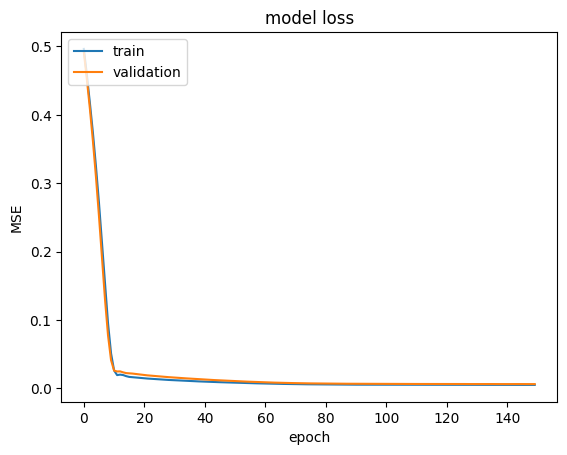

In [18]:
from matplotlib import pyplot as plt
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('MSE')
plt.xlabel('epoch')
plt.legend(['train', 'validation'], loc='upper left')
plt.show()

In [19]:
pred=model.predict(X_test)

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step


In [20]:
from sklearn.metrics import r2_score
# real value
print('\nThe R^2 score is {}'.format(r2_score(y_test,pred)))

# 1%


The R^2 score is 0.8116045270766243
